# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df=pd.read_csv("C:\\Users\\vr204\\OneDrive\\Desktop\\data.csv")
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
# Dataset information
# column names
print(df.columns)

# dataset shape
print(df.shape)

# info
df.info()


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')
(41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  

In [3]:
#Data Cleaning
df.isnull().sum()
#replace unknown valuses
df = df.replace("unknown", "Others")

In [4]:
# Statistical summary
print(df.describe())



               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000  
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911  
std        1.570960        0.578840       4.628198    

## Customer Demographics Analysis

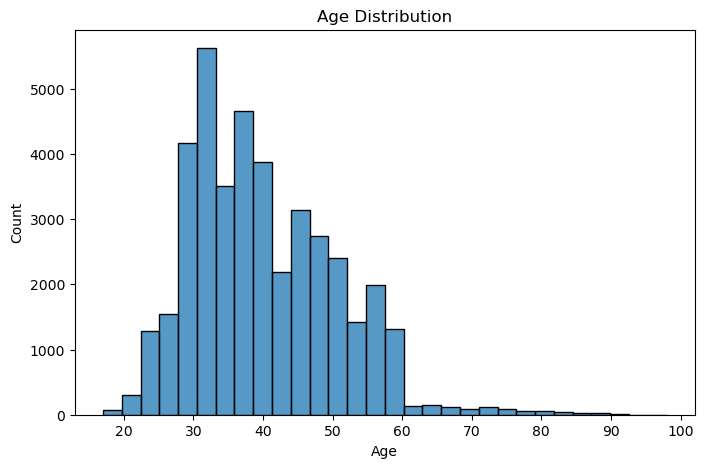

In [5]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

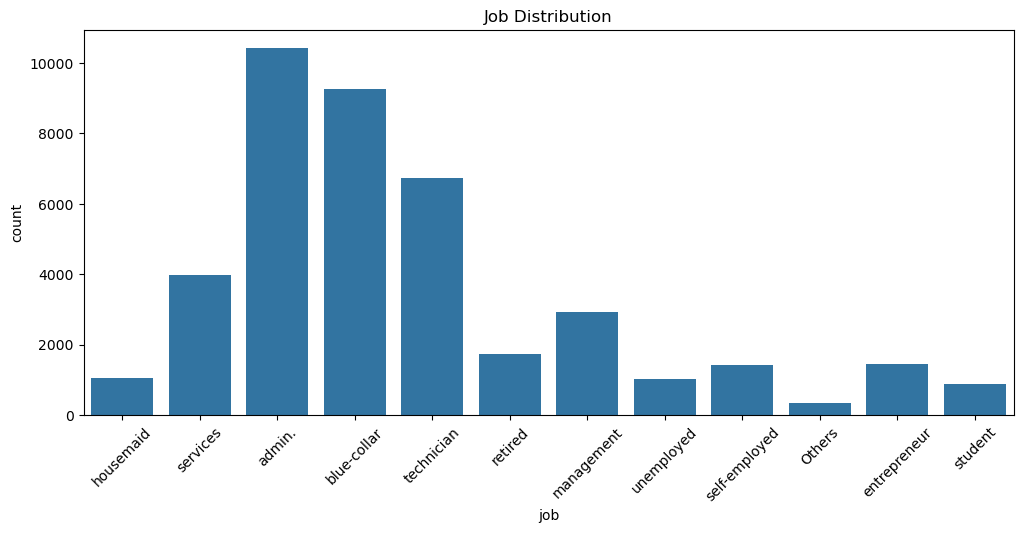

In [6]:
# Job distribution
plt.figure(figsize=(12,5))
sns.countplot(x='job', data=df)
plt.xticks(rotation=45)
plt.title("Job Distribution")
plt.show()

## Balance & Deposit Trends

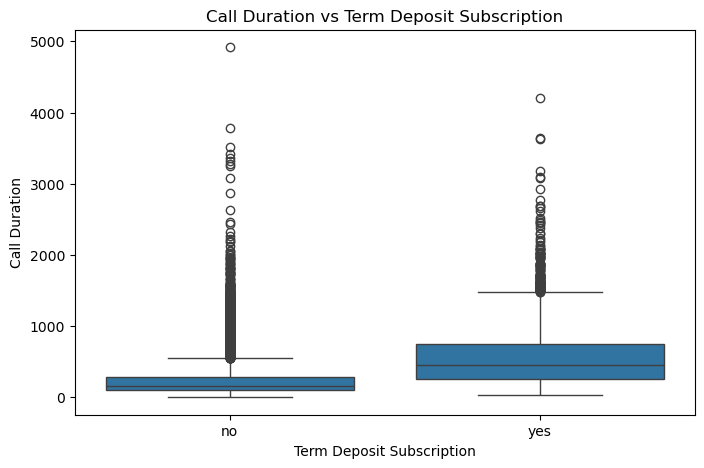

In [14]:
# Call Duration vs Term Deposit Subscription

plt.figure(figsize=(8,5))

sns.boxplot(x='y', y='duration', data=df)

plt.title("Call Duration vs Term Deposit Subscription")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Call Duration")

plt.show()

In [7]:
# Average balance by deposit subscription


## Campaign Effectiveness

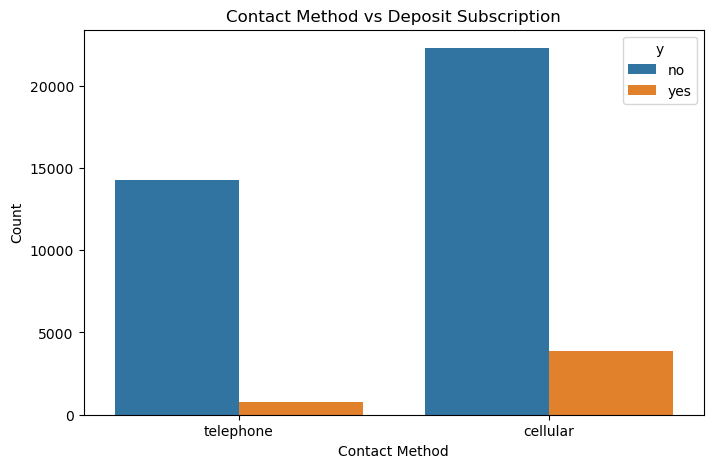

In [15]:
# Contact method analysis

plt.figure(figsize=(8,5))

sns.countplot(x='contact', hue='y', data=df)

plt.title("Contact Method vs Deposit Subscription")
plt.xlabel("Contact Method")
plt.ylabel("Count")

plt.show()


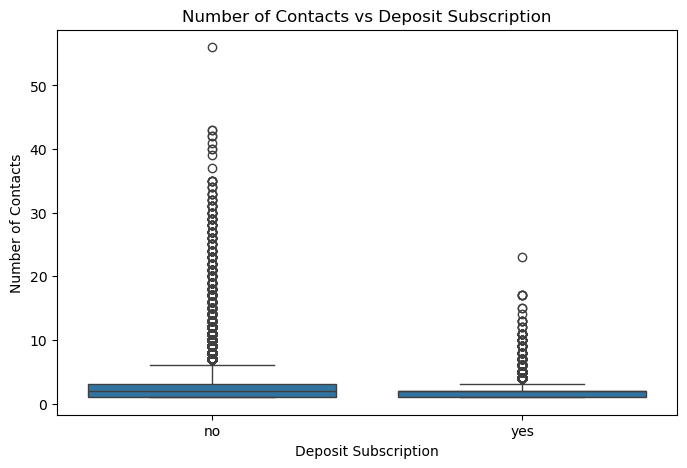

In [16]:
# Number of contacts vs deposit subscription

plt.figure(figsize=(8,5))

sns.boxplot(x='y', y='campaign', data=df)

plt.title("Number of Contacts vs Deposit Subscription")
plt.xlabel("Deposit Subscription")
plt.ylabel("Number of Contacts")

plt.show()

## Correlation Heatmap

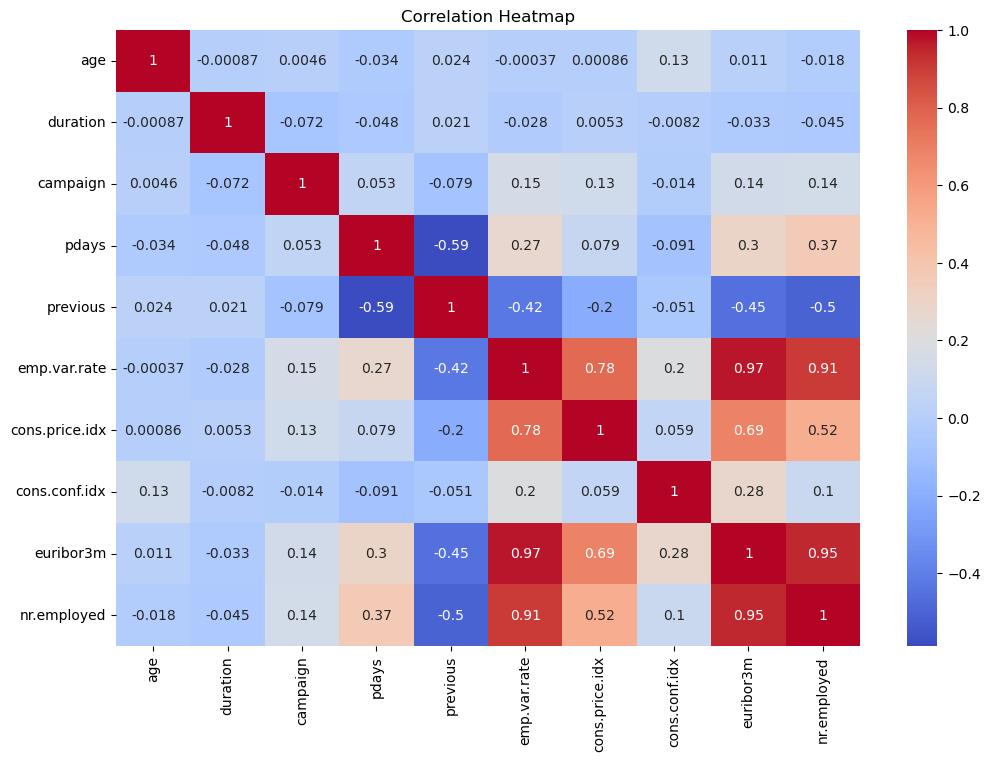

In [17]:
# Correlation of numerical variables

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()


## Predictive Modeling (Logistic Regression)

In [23]:
# Encode categorical variables

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

    #Predictions
    # Define features and target variable
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
X = df.drop('y', axis=1)
y = df['y']

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression model

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Train model

model.fit(X_train, y_train)

# Predictions

y_pred = model.predict(X_test)

# Model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Classification report

print(classification_report(y_test, y_pred))

Model Accuracy: 0.8509346928866229
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7303
           1       0.42      0.88      0.57       935

    accuracy                           0.85      8238
   macro avg       0.70      0.86      0.74      8238
weighted avg       0.92      0.85      0.87      8238



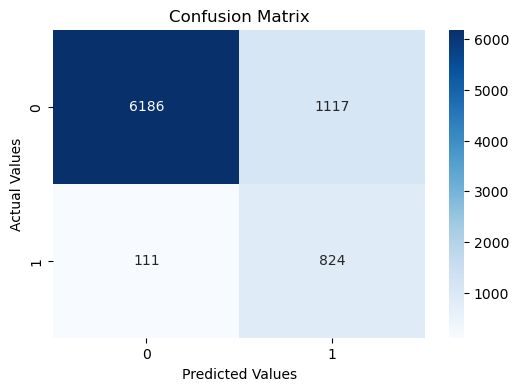

In [24]:
# Confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.show()

In [25]:
# Feature importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

           Feature  Importance
18       euribor3m    2.741082
10        duration    1.732812
16  cons.price.idx    0.240916
4          default    0.183847
14        poutcome    0.179660
3        education    0.124275
2          marital    0.085618
0              age    0.061334
1              job    0.051334
9      day_of_week    0.040939


## Conclusion

This project predicts whether a customer will subscribe to a bank term deposit
using Logistic Regression. Data preprocessing techniques such as encoding,
duplicate removal, and feature scaling were applied before training the model.
The model was evaluated using accuracy score, classification report,
correlation analysis, and confusion matrix.

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.